### CNNs applied to time series

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten #, Reshape
from tensorflow.keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras import regularizers as k_reg, initializers as k_init, optimizers as k_opt, losses as k_loss
# ---> (NB careful with alias names same as variables..)
###########################################################################
## from keras import regularizers, initializers
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)
###########################################################################
import pandas as pd
from scipy import stats
import seaborn 
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing
###################################################################
%run plot.py

### Read data

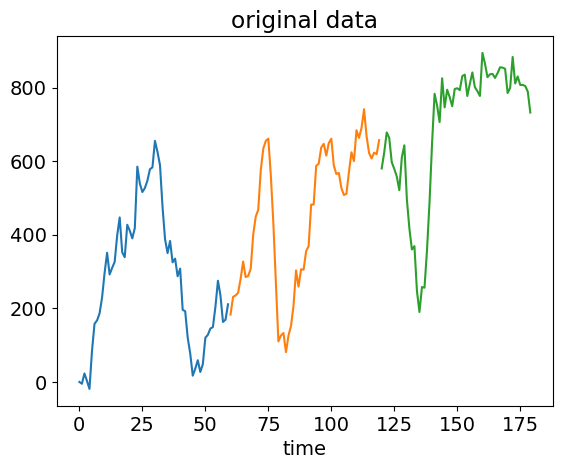

data:  10000


In [2]:
# ---> review "subtleties"?
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding (NB subtle)

### Split train-validation and rescale

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 588.25397835931 44.84287073276593 201.46657645528722
std_val average and mean: 569.9090424503428 55.06717110341998 201.92178219610327


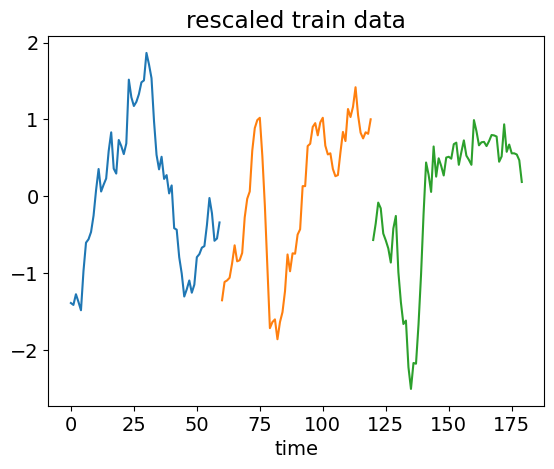

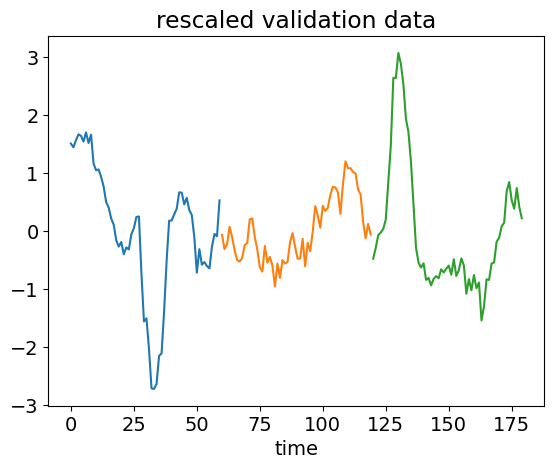

In [3]:
# ---> NB here validation is enough, no need for test set # ---> huh??
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

# ---> (two steps) rescaling:
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    # ---> NB to account for drift + varying jump length; to avoid "smoothing out" the pattern
    #      (would otherwise take more time to converge / get worse loss);
    #      ie must divide ALL samples by the same quantity # ---> review quickly?
for i in range(N_val):
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)

## Convolutional NN

In [4]:
# ...LESSON ...
# Hyper-parameters
# NB with small minibatch it does not converge!! 
BATCH_SIZE = 100 #200
EPOCHS = 50 #150
NCONV = 1 #switch between 1 and 2 type of CNNs
NF = 5 #number of filters

In [5]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()

In [6]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('Epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()

In [7]:
def plot_final_accuracy(lbd, fit, ax, clr='black', lbl=''):
    # plot final validation accuracy for a given lambda, on a given ax (ie, a single point)
    ax.scatter(lbd, fit.history['val_accuracy'][-1], color=clr, label=lbl) # ---> is there a lighter way??
    #ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")

In [8]:
def plot_final_params(mod, lbd, ax, l=0, clr1='black', clr2='blue', clr3='red',
                      lbl1=f'Weights of layer', lbl2=f'Bias of layer', lbl3=f'Variance of weights of layer'):
    # plot final weights (as dots of different colors) for a given lambda, on a given ax (ie multiple points aligned vertically)
    w = mod.layers[l].get_weights()[0].flatten() # weights of layer l (numpy array) ---> NB has shape
    w_var=np.var(w)
    b = mod.layers[l].get_weights()[1].flatten() # bias of layer l
    ax.scatter(np.broadcast_to(lbd, shape=len(w)), w, color=clr1, label= lbl1+' '+str(l)) 
    ax.scatter(np.broadcast_to(lbd, shape=len(b)), b, color=clr2, label= lbl2+' '+str(l))
    ax.scatter(lbd, w_var, color=clr3, marker='x', label=lbl3+' '+str(l)) # ---> NB "marker="

In [9]:
def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    seaborn.heatmap(matrix,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [10]:
def blank_final_figure(column_titles=['L1 regularisation', 'L2 regularisation']):#, rows_legends_on=True):
    fig, axes = plt.subplots(2,2, figsize=(15,10))
    ((ax1,ax2),(ax3,ax4)) = axes
    ax1.set_title(column_titles[0], fontsize=16)
    ax2.set_title(column_titles[1], fontsize=16)

    #ax1.set_xlabel('Lambda parameter')
    ax1.set_ylabel("Final val. accuracy")
    #ax2.set_xlabel('Lambda parameter')
    #ax2.set_ylabel("Final val. accuracy")
    ax3.set_xlabel('Lambda parameter')
    ax3.set_ylabel("Final weights")
    ax4.set_xlabel('Lambda parameter')
    #ax4.set_ylabel("Final weights")
    
    for axis in fig.axes:
        axis.set_xscale('log')
    #ax1.set_ylim([0, 1])
    #ax2.set_ylim([0, 1])

    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.8) # ---> NB this
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

    #if rows_legends_on:
    #    ax1.legend(loc='lower right')
    #    ax3.legend(loc='lower right') # ----> TODO: create legend for the single figure more efficiently??
    return fig, axes

In [11]:
#def show_final_figure(figure):
#    figure.show()

In [59]:
#final_fig, axes = blank_final_figure()

In [13]:
# ...LESSON ...
# reproducibility

# ---> why "#" vs "##" ?

# ---> NB HERE is the lambda parameter to try 
lambda_vals=[float(10**exp) for exp in range(1, -9, -1)]#+[0]
print(lambda_vals)
reg_l1_list=[k_reg.l1(lbd) for lbd in lambda_vals]
reg_l2_list=[k_reg.l2(lbd) for lbd in lambda_vals]
reg_list=reg_l1_list+reg_l2_list # ---> NB this
# ---> (NB the -1 and -6 not included)
#reg = tf.keras.regularizers.l2(0.2) ## raised to 0.2 the regularization strengths
#reg = regularizers.l1(0.1)
ini = k_init.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
((ax1,ax2),(ax3,ax4)) = axes # ---> TODO: put inside somewhere??

[10.0, 1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08]


In [14]:
# challenge: at most 600 tunable parameters ---> ??

# ----> NB easiear to debug / avoids retraining would be to save all necessary quantities in arrays
#       THEN plot using a function that takes them as parameters(??!!!)
for i in range(len(reg_list)):
    model = Sequential()
    reg=reg_list[i]
    ll=len(reg_list)
    print(f"=================================Doing model number {i} of {ll}=====================================")
    # ---> TODO: pretty print(??)
    if NCONV==1:
        # -----2-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg, # ---> loops over this
                         activation='relu', 
                         input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, 
                         activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    
    if NCONV==2:
        # -----1-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg, ######## TRY WITHOUT ! (?)
                         activation='relu', input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))
        #model.add(Dense(10, activation='relu'))
        #model.add(Dropout(0.3))
    model.add(Dense(n_class, activation='softmax')) # NB softmax !
    
    #print('----- Model',NCONV,'-----')
    #print(model.summary())
    
    # optimizers
    # .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
    # .RMSprop()
    # .Nadam()
    opt = k_opt.Adam()
    
    # compile the model
    # categorical_crossentropy, 3 output nodes
    model.compile(loss=k_loss.categorical_crossentropy,
                  optimizer=opt,metrics=['accuracy'])
    #model.layers
            
    #Show_weights(model,0)
    #Show_weights(model,2)
    # ---> TODO: count params?

    #print('----- Model ',NCONV,'-----\nFITTING....')
    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True) 
    if (i<len(reg_l1_list)): # ---> NB "<" not "<="
        plot_final_accuracy(lambda_vals[i], fit, ax1) # ---> (NB the value of the lambda as x coordinate, not the reg object; "model")
        plot_final_params(model, lambda_vals[i], ax3)
    else:
        plot_final_accuracy(lambda_vals[i - len(reg_l1_list)], fit, ax2)
        plot_final_params(model, lambda_vals[i - len(reg_l1_list)], ax4)
    # ---> TODO: generalise to other regularisation procedures (eg l1_l2)??
    # ---> TODO: plot for all layers?? but how??
    #Show_history(fit)
    #Show_weights(model,0)
    #Show_weights(model,2)
    
    # confusion table: compare true labels with predicted ones
    LABELS = ["absent","positive","negative"] # from labels y 
    cmap="GnBu"
    
    y_pred_val = model.predict(x_val)
    #y_pred_val2 = model2.predict(x_val)
    # Take the class with the highest probability from the val predictions
    max_y_pred_val = np.argmax(y_pred_val, axis=1)
    max_y_val = np.argmax(y_val, axis=1)
    #max_y_pred_val2 = np.argmax(y_pred_val2, axis=1)
    
    #show_confusion_matrix(max_y_val, max_y_pred_val)
    #show_confusion_matrix(max_y_val, max_y_pred_val2, label="Model 2")
    
    #print(classification_report(max_y_val, max_y_pred_val))
    # ---> TODO: split in multiple cells?? (but it's a for cycle..)

=================================Doing model number 0 of 20=====================================


C:\Users\Libero\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
=================================Doing model number 1 of 20=====================================
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
=================================Doing model number 2 of 20=====================================
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=================================Doing model number 3 of 20=====================================
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
=================================Doing model number 4 of 20=====================================
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=================================Doing model number 5 of 20=====================================
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  
=================================Doing model number 6 of 20=====================================
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=================================Doing model number 7 of 20=====================================
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

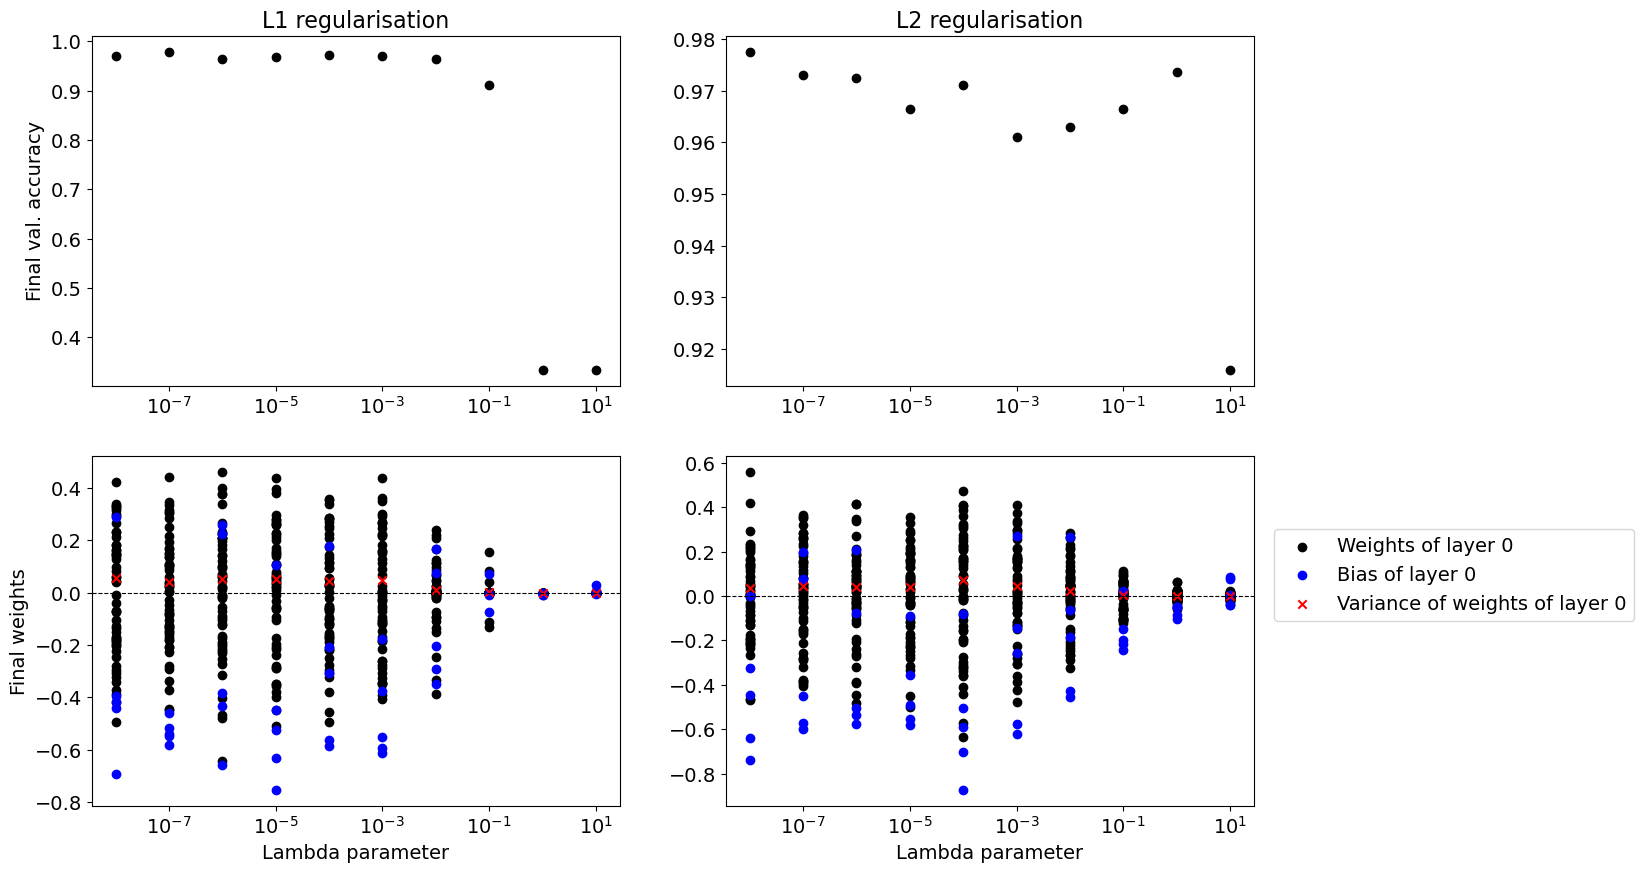

In [58]:
# ---> NB to avoid duplicate labels:

# Remove any existing legends 
for ax in [ax1,ax2, ax3, ax4]:
    if ax.legend_:
        ax.legend_.remove()

if final_fig.legends:
    final_fig.legends.clear()

# Get unique handles and labels from ax4
handles, labels = [], []
seen = set()
for h, l in zip(*ax4.get_legend_handles_labels()):
    if l not in seen:
        seen.add(l)
        handles.append(h)
        labels.append(l)

# Create new legend on ax4
ax4.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='lower left')
final_fig